# Notebook 08 - Cohort Retention Analysis

## Objective
The goal of this notebook is to perform **customer cohort retention analysis** on the Olist e-commerce dataset.

A cohort is a group of customers who made their **first purchase in the same month**.  
By tracking these cohorts over time, we can measure how many customers return and continue purchasing in later months.

## Business Questions
This notebook answers questions such as:
- How strong is customer retention after the first purchase?
- Which customer cohorts show better repeat purchase behavior?
- How quickly does customer activity decline after acquisition?
- Are some acquisition months stronger than others in long-term retention?

## Business Value
Cohort retention analysis helps the business:
- measure customer stickiness
- understand repeat purchase patterns
- identify weak retention after acquisition
- support customer lifecycle, loyalty, and reactivation strategies

## Notebook Scope
In this notebook, we will:
- prepare a clean customer-order transaction base
- create monthly customer cohorts
- calculate cohort index values
- build a cohort retention matrix
- visualize retention using a heatmap
- interpret retention patterns and business implications

In [11]:
# ======================================================
# Section 2 - Import Libraries
# ======================================================

import warnings
warnings.filterwarnings("ignore")

from pathlib import Path
import os

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.float_format", "{:,.2f}".format)

In [12]:
# ======================================================
# Section 3 - Define Paths and Load Files
# ======================================================

DATA_DIR = Path(r"C:\Users\divya\Downloads\Retail-Intelligence-Platform\data\raw")

customers_path = DATA_DIR / "olist_customers_dataset.csv"
orders_path = DATA_DIR / "olist_orders_dataset.csv"

customers = pd.read_csv(customers_path)
orders = pd.read_csv(orders_path)

print("Customers shape:", customers.shape)
print("Orders shape   :", orders.shape)

display(customers.head())
display(orders.head())

Customers shape: (99441, 5)
Orders shape   : (99441, 8)


,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [13]:
# ======================================================
# Section 4 - Inspect Relevant Columns
# ======================================================

print("Customers columns:")
print(customers.columns.tolist())

print("\nOrders columns:")
print(orders.columns.tolist())

Customers columns:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Orders columns:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']


In [14]:
# ======================================================
# Section 5 - Convert Date Columns
# ======================================================

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"],
    errors="coerce"
)

print("Null order_purchase_timestamp values:", orders["order_purchase_timestamp"].isna().sum())

display(
    orders[["order_id", "customer_id", "order_status", "order_purchase_timestamp"]].head()
)

Null order_purchase_timestamp values: 0


,order_id,customer_id,order_status,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39


In [15]:
# ======================================================
# Section 6 - Filter Delivered Orders
# ======================================================

orders_delivered = orders.loc[
    orders["order_status"] == "delivered",
    ["order_id", "customer_id", "order_status", "order_purchase_timestamp"]
].copy()

print("Delivered orders shape:", orders_delivered.shape)
display(orders_delivered.head())

Delivered orders shape: (96478, 4)


,order_id,customer_id,order_status,order_purchase_timestamp
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39


In [16]:
# ======================================================
# Section 7 - Build Cohort Base Table
# ======================================================

cohort_base = (
    orders_delivered
    .merge(
        customers[["customer_id", "customer_unique_id"]],
        on="customer_id",
        how="left"
    )
)

print("Cohort base shape:", cohort_base.shape)
display(cohort_base.head())

Cohort base shape: (96478, 5)


,order_id,customer_id,order_status,order_purchase_timestamp,customer_unique_id
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6


In [17]:
# ======================================================
# Section 8 - Drop Critical Nulls
# ======================================================

cohort_base = cohort_base.dropna(
    subset=["customer_unique_id", "order_purchase_timestamp"]
).copy()

print("Cohort base shape after null removal:", cohort_base.shape)

print("\nNull summary:")
display(cohort_base.isnull().sum())

Cohort base shape after null removal: (96478, 5)

Null summary:


order_id                    0
customer_id                 0
order_status                0
order_purchase_timestamp    0
customer_unique_id          0
dtype: int64

In [18]:
# ======================================================
# Section 9 - Create Order Month
# ======================================================

cohort_base["OrderMonth"] = cohort_base["order_purchase_timestamp"].dt.to_period("M").dt.to_timestamp()

display(
    cohort_base[
        ["customer_unique_id", "order_purchase_timestamp", "OrderMonth"]
    ].head()
)

,customer_unique_id,order_purchase_timestamp,OrderMonth
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-02 10:56:33,2017-10-01
1,af07308b275d755c9edb36a90c618231,2018-07-24 20:41:37,2018-07-01
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-08 08:38:49,2018-08-01
3,7c142cf63193a1473d2e66489a9ae977,2017-11-18 19:28:06,2017-11-01
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-13 21:18:39,2018-02-01


In [19]:
# ======================================================
# Section 10 - Create Cohort Month
# ======================================================

cohort_base["CohortMonth"] = (
    cohort_base.groupby("customer_unique_id")["OrderMonth"]
    .transform("min")
)

display(
    cohort_base[
        ["customer_unique_id", "OrderMonth", "CohortMonth"]
    ].head(10)
)

,customer_unique_id,OrderMonth,CohortMonth
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-01,2017-09-01
1,af07308b275d755c9edb36a90c618231,2018-07-01,2018-07-01
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-01,2018-08-01
3,7c142cf63193a1473d2e66489a9ae977,2017-11-01,2017-11-01
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-01,2018-02-01
5,80bb27c7c16e8f973207a5086ab329e2,2017-07-01,2017-07-01
6,932afa1e708222e5821dac9cd5db4cae,2017-05-01,2017-05-01
7,39382392765b6dc74812866ee5ee92a7,2017-01-01,2017-01-01
8,299905e3934e9e181bfb2e164dd4b4f8,2017-07-01,2017-07-01
9,f2a85dec752b8517b5e58a06ff3cd937,2017-05-01,2017-05-01


In [20]:
# ======================================================
# Section 11 - Create Cohort Index
# ======================================================

order_year = cohort_base["OrderMonth"].dt.year
order_month = cohort_base["OrderMonth"].dt.month

cohort_year = cohort_base["CohortMonth"].dt.year
cohort_month = cohort_base["CohortMonth"].dt.month

year_diff = order_year - cohort_year
month_diff = order_month - cohort_month

cohort_base["CohortIndex"] = year_diff * 12 + month_diff + 1

display(
    cohort_base[
        ["customer_unique_id", "OrderMonth", "CohortMonth", "CohortIndex"]
    ].head(15)
)

,customer_unique_id,OrderMonth,CohortMonth,CohortIndex
0,7c396fd4830fd04220f754e42b4e5bff,2017-10-01,2017-09-01,2
1,af07308b275d755c9edb36a90c618231,2018-07-01,2018-07-01,1
2,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-01,2018-08-01,1
3,7c142cf63193a1473d2e66489a9ae977,2017-11-01,2017-11-01,1
4,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-01,2018-02-01,1
5,80bb27c7c16e8f973207a5086ab329e2,2017-07-01,2017-07-01,1
6,932afa1e708222e5821dac9cd5db4cae,2017-05-01,2017-05-01,1
7,39382392765b6dc74812866ee5ee92a7,2017-01-01,2017-01-01,1
8,299905e3934e9e181bfb2e164dd4b4f8,2017-07-01,2017-07-01,1
9,f2a85dec752b8517b5e58a06ff3cd937,2017-05-01,2017-05-01,1


In [21]:
# ======================================================
# Section 12 - Build Cohort Counts Table
# ======================================================

cohort_counts = (
    cohort_base
    .groupby(["CohortMonth", "CohortIndex"])["customer_unique_id"]
    .nunique()
    .reset_index()
)

cohort_counts.columns = ["CohortMonth", "CohortIndex", "Customers"]

print("Cohort counts shape:", cohort_counts.shape)
display(cohort_counts.head(15))

Cohort counts shape: (219, 3)


,CohortMonth,CohortIndex,Customers
0,2016-09-01,1,1
1,2016-10-01,1,262
2,2016-10-01,7,1
3,2016-10-01,10,1
4,2016-10-01,12,1
5,2016-10-01,14,1
6,2016-10-01,16,1
7,2016-10-01,18,1
8,2016-10-01,20,2
9,2016-10-01,21,2


In [22]:
# ======================================================
# Section 13 - Create Cohort Matrix
# ======================================================

cohort_matrix = cohort_counts.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="Customers"
)

display(cohort_matrix.head())

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
CohortMonth,,,,,,,,,,,,,,,,,,,,
2016-09-01,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,262.00,NaN,NaN,NaN,NaN,NaN,1.00,NaN,NaN,1.00,NaN,1.00,NaN,1.00,NaN,1.00,NaN,1.00,2.00,2.00
2016-12-01,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,717.00,2.00,2.00,1.00,3.00,1.00,3.00,1.00,1.00,NaN,3.00,1.00,5.00,3.00,1.00,1.00,2.00,3.00,1.00,NaN
2017-02-01,"1,628.00",3.00,5.00,2.00,7.00,2.00,4.00,3.00,2.00,3.00,2.00,5.00,2.00,3.00,2.00,1.00,1.00,3.00,NaN,NaN


In [23]:
# ======================================================
# Section 14 - Create Retention Matrix
# ======================================================

cohort_sizes = cohort_matrix.iloc[:, 0]

retention_matrix = cohort_matrix.divide(cohort_sizes, axis=0)

display(retention_matrix.head())

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
CohortMonth,,,,,,,,,,,,,,,,,,,,
2016-09-01,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,1.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,NaN,0.00,0.01,0.01
2016-12-01,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.01,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2017-02-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN


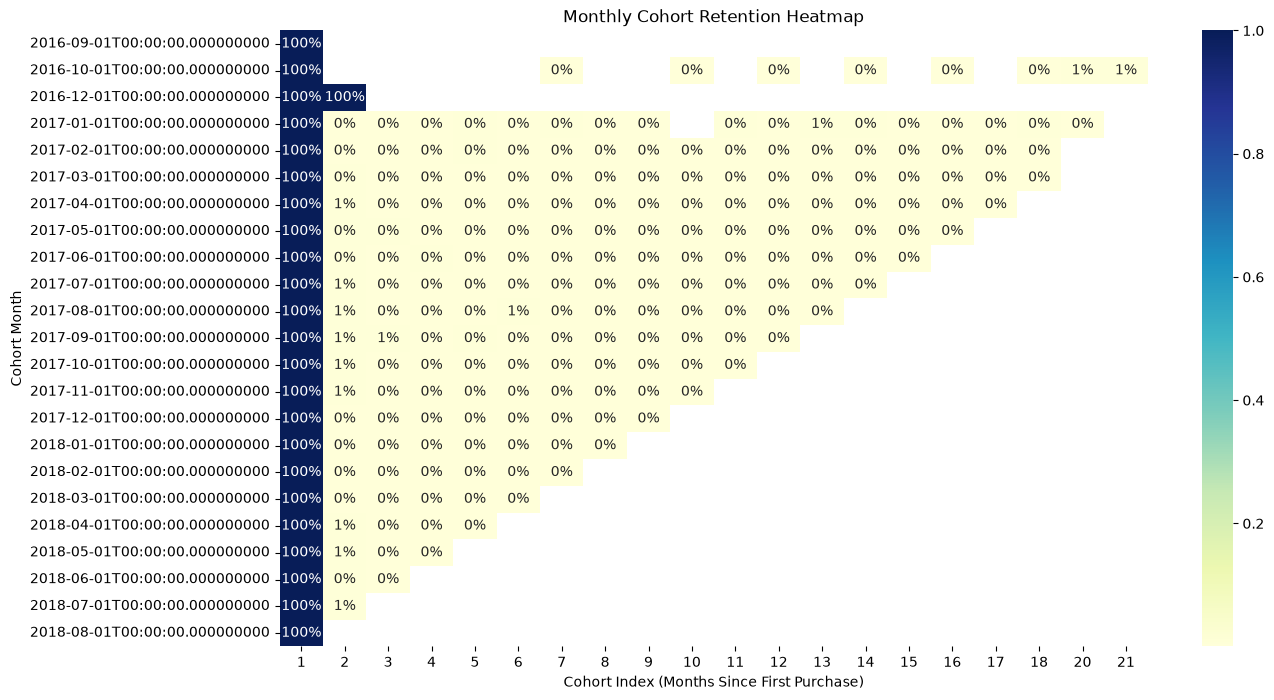

In [24]:
# ======================================================
# Section 15 - Plot Retention Heatmap
# ======================================================

plt.figure(figsize=(14, 8))

sns.heatmap(
    retention_matrix,
    annot=True,
    fmt=".0%",
    cmap="YlGnBu"
)

plt.title("Monthly Cohort Retention Heatmap")
plt.xlabel("Cohort Index (Months Since First Purchase)")
plt.ylabel("Cohort Month")
plt.yticks(rotation=0)
plt.show()

,CohortMonth,Customers
0,2016-09-01,1.00
1,2016-10-01,262.00
2,2016-12-01,1.00
3,2017-01-01,717.00
4,2017-02-01,"1,628.00"
5,2017-03-01,"2,503.00"
6,2017-04-01,"2,256.00"
7,2017-05-01,"3,451.00"
8,2017-06-01,"3,037.00"
9,2017-07-01,"3,752.00"


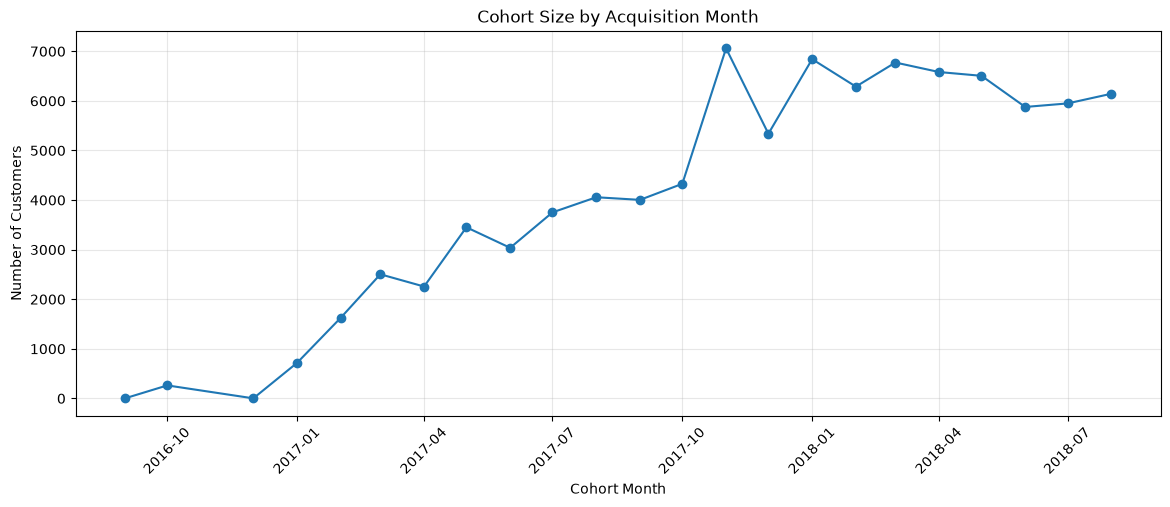

In [25]:
# ======================================================
# Section 16 - Cohort Size Analysis
# ======================================================

cohort_size_df = cohort_sizes.reset_index()
cohort_size_df.columns = ["CohortMonth", "Customers"]

display(cohort_size_df.head(15))

plt.figure(figsize=(14, 5))
plt.plot(cohort_size_df["CohortMonth"], cohort_size_df["Customers"], marker="o")
plt.title("Cohort Size by Acquisition Month")
plt.xlabel("Cohort Month")
plt.ylabel("Number of Customers")
plt.grid(True, alpha=0.3)
plt.xticks(rotation=45)
plt.show()

In [26]:
# ======================================================
# Section 17 - Average Retention by Cohort Index
# ======================================================

avg_retention_by_index = retention_matrix.mean(axis=0).reset_index()
avg_retention_by_index.columns = ["CohortIndex", "AverageRetention"]

avg_retention_by_index["AverageRetentionPct"] = (
    avg_retention_by_index["AverageRetention"] * 100
).round(2)

display(avg_retention_by_index)

,CohortIndex,AverageRetention,AverageRetentionPct
0,1,1.00,100.00
1,2,0.05,5.45
2,3,0.00,0.34
3,4,0.00,0.25
4,5,0.00,0.29
5,6,0.00,0.23
6,7,0.00,0.27
7,8,0.00,0.21
8,9,0.00,0.21
9,10,0.00,0.19


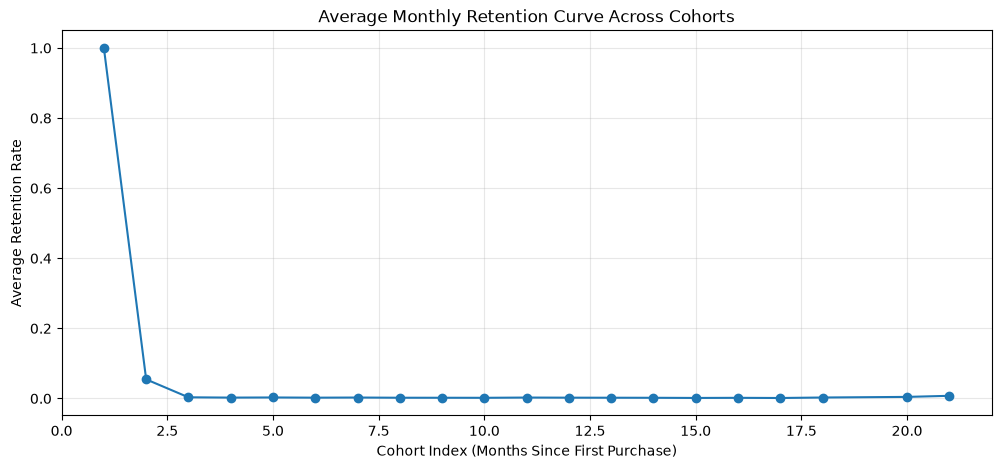

In [27]:
# ======================================================
# Section 18 - Plot Overall Retention Curve
# ======================================================

plt.figure(figsize=(12, 5))
plt.plot(
    avg_retention_by_index["CohortIndex"],
    avg_retention_by_index["AverageRetention"],
    marker="o"
)

plt.title("Average Monthly Retention Curve Across Cohorts")
plt.xlabel("Cohort Index (Months Since First Purchase)")
plt.ylabel("Average Retention Rate")
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
# ======================================================
# Section 19 - Best and Worst Cohorts by Month-2 Retention
# ======================================================

# CohortIndex = 2 means first month after acquisition month
if 2 in retention_matrix.columns:
    month2_retention = retention_matrix[2].dropna().sort_values(ascending=False)

    best_cohorts = month2_retention.head(5).reset_index()
    best_cohorts.columns = ["CohortMonth", "Month2Retention"]

    worst_cohorts = month2_retention.tail(5).reset_index()
    worst_cohorts.columns = ["CohortMonth", "Month2Retention"]

    print("Top 5 Cohorts by Month-2 Retention")
    display(best_cohorts)

    print("Bottom 5 Cohorts by Month-2 Retention")
    display(worst_cohorts)
else:
    print("CohortIndex 2 not available in retention_matrix.")

Top 5 Cohorts by Month-2 Retention


,CohortMonth,Month2Retention
0,2016-12-01,1.00
1,2017-10-01,0.01
2,2017-09-01,0.01
3,2017-08-01,0.01
4,2017-04-01,0.01


Bottom 5 Cohorts by Month-2 Retention


,CohortMonth,Month2Retention
0,2018-02-01,0.00
1,2018-01-01,0.00
2,2017-01-01,0.00
3,2017-12-01,0.00
4,2017-02-01,0.00


In [29]:
# ======================================================
# Section 20 - Repeat Purchase Count per Customer
# ======================================================

customer_order_counts = (
    cohort_base.groupby("customer_unique_id")["order_id"]
    .nunique()
    .reset_index()
)

customer_order_counts.columns = ["customer_unique_id", "OrderCount"]

display(customer_order_counts.head())

print("Order count distribution:")
display(customer_order_counts["OrderCount"].value_counts().sort_index().head(20))

,customer_unique_id,OrderCount
0,0000366f3b9a7992bf8c76cfdf3221e2,1
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1
2,0000f46a3911fa3c0805444483337064,1
3,0000f6ccb0745a6a4b88665a16c9f078,1
4,0004aac84e0df4da2b147fca70cf8255,1


Order count distribution:


OrderCount
1     90557
2      2573
3       181
4        28
5         9
6         5
7         3
9         1
15        1
Name: count, dtype: int64

In [30]:
# ======================================================
# Section 21 - Repeat Purchase Rate
# ======================================================

total_customers = customer_order_counts["customer_unique_id"].nunique()
repeat_customers = customer_order_counts.loc[
    customer_order_counts["OrderCount"] > 1,
    "customer_unique_id"
].nunique()

repeat_purchase_rate = repeat_customers / total_customers

repeat_summary = pd.DataFrame({
    "Total_Customers": [total_customers],
    "Repeat_Customers": [repeat_customers],
    "Repeat_Purchase_Rate": [round(repeat_purchase_rate * 100, 2)]
})

display(repeat_summary)

,Total_Customers,Repeat_Customers,Repeat_Purchase_Rate
0,93358,2801,3.00


In [31]:
# ======================================================
# Section 22A - Load Payments and Build Revenue Cohort Base
# ======================================================

payments_path = DATA_DIR / "olist_order_payments_dataset.csv"
payments = pd.read_csv(payments_path)

payments_agg = (
    payments.groupby("order_id", as_index=False)["payment_value"]
    .sum()
)

cohort_revenue_base = cohort_base.merge(
    payments_agg,
    on="order_id",
    how="left"
)

cohort_revenue_base["payment_value"] = cohort_revenue_base["payment_value"].fillna(0)

print("Revenue cohort base shape:", cohort_revenue_base.shape)
display(cohort_revenue_base.head())

Revenue cohort base shape: (96478, 9)


,order_id,customer_id,order_status,order_purchase_timestamp,customer_unique_id,OrderMonth,CohortMonth,CohortIndex,payment_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,7c396fd4830fd04220f754e42b4e5bff,2017-10-01,2017-09-01,2,38.71
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,af07308b275d755c9edb36a90c618231,2018-07-01,2018-07-01,1,141.46
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,3a653a41f6f9fc3d2a113cf8398680e8,2018-08-01,2018-08-01,1,179.12
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,7c142cf63193a1473d2e66489a9ae977,2017-11-01,2017-11-01,1,72.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,72632f0f9dd73dfee390c9b22eb56dd6,2018-02-01,2018-02-01,1,28.62


In [32]:
# ======================================================
# Section 22B - Build Cohort Revenue Table
# ======================================================

cohort_revenue = (
    cohort_revenue_base
    .groupby(["CohortMonth", "CohortIndex"])["payment_value"]
    .sum()
    .reset_index()
)

cohort_revenue.columns = ["CohortMonth", "CohortIndex", "Revenue"]

display(cohort_revenue.head(15))

,CohortMonth,CohortIndex,Revenue
0,2016-09-01,1,0.00
1,2016-10-01,1,"46,566.71"
2,2016-10-01,7,111.30
3,2016-10-01,10,356.13
4,2016-10-01,12,56.78
5,2016-10-01,14,163.53
6,2016-10-01,16,381.00
7,2016-10-01,18,116.57
8,2016-10-01,20,384.01
9,2016-10-01,21,181.37


In [33]:
# ======================================================
# Section 23 - Create Revenue Cohort Matrix
# ======================================================

revenue_matrix = cohort_revenue.pivot(
    index="CohortMonth",
    columns="CohortIndex",
    values="Revenue"
)

display(revenue_matrix.head())

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
CohortMonth,,,,,,,,,,,,,,,,,,,,
2016-09-01,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,"46,566.71",NaN,NaN,NaN,NaN,NaN,111.30,NaN,NaN,356.13,NaN,56.78,NaN,163.53,NaN,381.00,NaN,116.57,384.01,181.37
2016-12-01,19.62,19.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,"127,526.05",111.07,114.70,89.70,246.25,69.33,448.43,105.17,47.05,NaN,427.05,66.60,552.45,351.65,93.70,104.61,219.35,354.43,50.93,NaN
2017-02-01,"271,187.58",481.68,570.63,118.73,"1,151.96",74.21,688.92,274.30,464.61,385.35,343.22,454.39,279.24,397.11,181.66,136.79,291.68,369.65,NaN,NaN


In [34]:
# ======================================================
# Section 24 - Revenue Retention Matrix
# ======================================================

cohort_revenue_start = revenue_matrix.iloc[:, 0]
revenue_retention_matrix = revenue_matrix.divide(cohort_revenue_start, axis=0)

display(revenue_retention_matrix.head())

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
CohortMonth,,,,,,,,,,,,,,,,,,,,
2016-09-01,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,1.00,NaN,NaN,NaN,NaN,NaN,0.00,NaN,NaN,0.01,NaN,0.00,NaN,0.00,NaN,0.01,NaN,0.00,0.01,0.00
2016-12-01,1.00,1.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN
2017-02-01,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,NaN,NaN


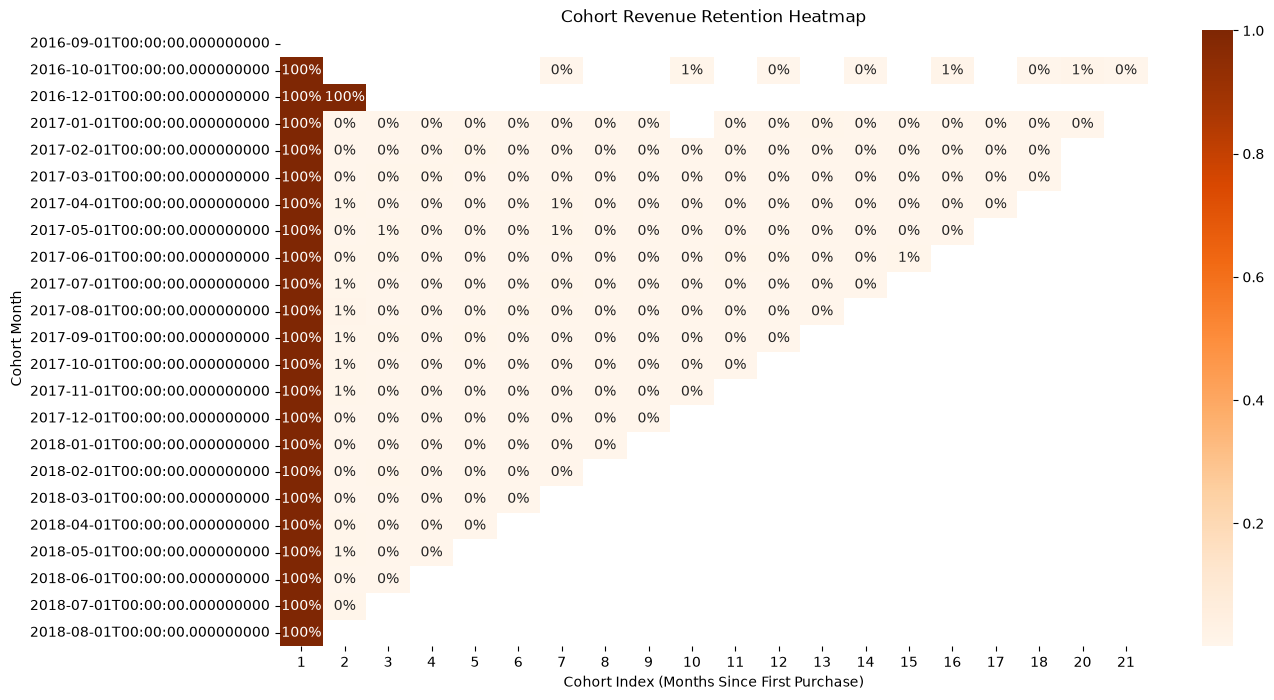

In [35]:
plt.figure(figsize=(14, 8))

sns.heatmap(
    revenue_retention_matrix,
    annot=True,
    fmt=".0%",
    cmap="Oranges"
)

plt.title("Cohort Revenue Retention Heatmap")
plt.xlabel("Cohort Index (Months Since First Purchase)")
plt.ylabel("Cohort Month")
plt.yticks(rotation=0)
plt.show()

CohortIndex,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15,16,17,18,20,21
CohortMonth,,,,,,,,,,,,,,,,,,,,
2016-09-01,0.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10-01,177.74,NaN,NaN,NaN,NaN,NaN,111.30,NaN,NaN,356.13,NaN,56.78,NaN,163.53,NaN,381.00,NaN,116.57,192.01,90.69
2016-12-01,19.62,19.62,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01-01,177.86,55.54,57.35,89.70,82.08,69.33,149.48,105.17,47.05,NaN,142.35,66.60,110.49,117.22,93.70,104.61,109.68,118.14,50.93,NaN
2017-02-01,166.58,160.56,114.13,59.36,164.57,37.11,172.23,91.43,232.31,128.45,171.61,90.88,139.62,132.37,90.83,136.79,291.68,123.22,NaN,NaN


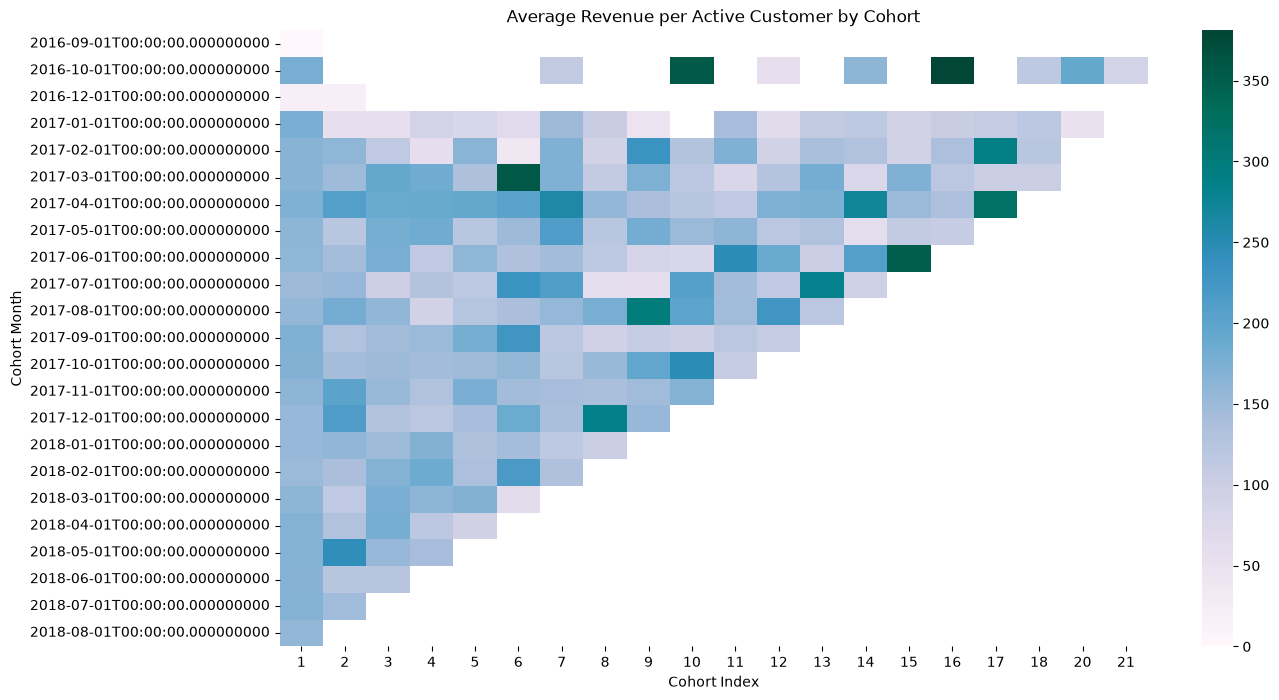

In [36]:
# ======================================================
# Section 25 - Revenue per Active Customer
# ======================================================

revenue_per_active_customer = revenue_matrix / cohort_matrix

display(revenue_per_active_customer.head())

plt.figure(figsize=(14, 8))
sns.heatmap(
    revenue_per_active_customer,
    annot=False,
    cmap="PuBuGn"
)
plt.title("Average Revenue per Active Customer by Cohort")
plt.xlabel("Cohort Index")
plt.ylabel("Cohort Month")
plt.yticks(rotation=0)
plt.show()

In [37]:
# ======================================================
# Section 26 - Strongest Cohorts
# ======================================================

if 2 in retention_matrix.columns:
    strongest_cohorts = (
        pd.DataFrame({
            "CohortMonth": retention_matrix.index,
            "Month2Retention": retention_matrix[2].values,
            "CohortSize": cohort_sizes.values
        })
        .sort_values(["Month2Retention", "CohortSize"], ascending=[False, False])
        .reset_index(drop=True)
    )

    display(strongest_cohorts.head(10))
else:
    print("Month-2 retention column not available.")

,CohortMonth,Month2Retention,CohortSize
0,2016-12-01,1.00,1.00
1,2017-10-01,0.01,"4,328.00"
2,2017-09-01,0.01,"4,004.00"
3,2017-08-01,0.01,"4,057.00"
4,2017-04-01,0.01,"2,256.00"
5,2018-04-01,0.01,"6,582.00"
6,2017-11-01,0.01,"7,060.00"
7,2017-07-01,0.01,"3,752.00"
8,2018-05-01,0.01,"6,506.00"
9,2018-07-01,0.01,"5,949.00"


In [38]:
# ======================================================
# Section 27 - Weakest Cohorts
# ======================================================

if 2 in retention_matrix.columns:
    weakest_cohorts = (
        pd.DataFrame({
            "CohortMonth": retention_matrix.index,
            "Month2Retention": retention_matrix[2].values,
            "CohortSize": cohort_sizes.values
        })
        .sort_values(["Month2Retention", "CohortSize"], ascending=[True, False])
        .reset_index(drop=True)
    )

    display(weakest_cohorts.head(10))
else:
    print("Month-2 retention column not available.")

,CohortMonth,Month2Retention,CohortSize
0,2017-02-01,0.00,"1,628.00"
1,2017-12-01,0.00,"5,338.00"
2,2017-01-01,0.00,717.00
3,2018-01-01,0.00,"6,842.00"
4,2018-02-01,0.00,"6,288.00"
5,2018-03-01,0.00,"6,774.00"
6,2018-06-01,0.00,"5,878.00"
7,2017-03-01,0.00,"2,503.00"
8,2017-05-01,0.00,"3,451.00"
9,2017-06-01,0.00,"3,037.00"


In [39]:
# ======================================================
# Section 28 - Cohort Business Summary
# ======================================================

cohort_business_summary = pd.DataFrame({
    "CohortMonth": cohort_sizes.index,
    "CohortSize": cohort_sizes.values
})

# Add month-2 and month-3 retention if available
if 2 in retention_matrix.columns:
    cohort_business_summary["Month2Retention"] = retention_matrix[2].values
else:
    cohort_business_summary["Month2Retention"] = np.nan

if 3 in retention_matrix.columns:
    cohort_business_summary["Month3Retention"] = retention_matrix[3].values
else:
    cohort_business_summary["Month3Retention"] = np.nan

# Add first cohort-month revenue if available
if 1 in revenue_matrix.columns:
    cohort_business_summary["Month1Revenue"] = revenue_matrix[1].values
else:
    cohort_business_summary["Month1Revenue"] = np.nan

display(cohort_business_summary.head(15))

,CohortMonth,CohortSize,Month2Retention,Month3Retention,Month1Revenue
0,2016-09-01,1.00,NaN,NaN,0.00
1,2016-10-01,262.00,NaN,NaN,"46,566.71"
2,2016-12-01,1.00,1.00,NaN,19.62
3,2017-01-01,717.00,0.00,0.00,"127,526.05"
4,2017-02-01,"1,628.00",0.00,0.00,"271,187.58"
5,2017-03-01,"2,503.00",0.00,0.00,"413,773.01"
6,2017-04-01,"2,256.00",0.01,0.00,"388,556.92"
7,2017-05-01,"3,451.00",0.00,0.00,"562,027.63"
8,2017-06-01,"3,037.00",0.00,0.00,"484,296.24"
9,2017-07-01,"3,752.00",0.01,0.00,"558,533.43"


In [43]:
# ======================================================
# NOTEBOOK 08 - FINAL SIMPLE EXPORT BLOCK
# Exports:
# 1) cohort_business_summary.csv
# 2) repeat_purchase_summary.csv
# Saves to:
#    C:\Users\divya\
# ======================================================

import csv
from pathlib import Path
import pandas as pd

print("======================================================")
print("NOTEBOOK 08 FINAL EXPORT BLOCK STARTED")
print("======================================================")

# ======================================================
# PART 1 - EXPORT cohort_business_summary.csv
# ======================================================

print("\n[1/2] Exporting cohort_business_summary.csv ...")

if "cohort_business_summary" not in globals():
    raise ValueError(
        "cohort_business_summary dataframe not found. "
        "Run the cohort summary section in Notebook 08 first, then run this export block."
    )

cohort_export = cohort_business_summary.copy()
cohort_export.columns = [str(c).strip() for c in cohort_export.columns]

print("cohort_business_summary shape:", cohort_export.shape)
display(cohort_export.head())

cohort_output_file = Path(r"C:\Users\divya\cohort_business_summary.csv")

with open(cohort_output_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(cohort_export.columns.tolist())
    writer.writerows(cohort_export.values.tolist())

print(f"Saved successfully to: {cohort_output_file}")


# ======================================================
# PART 2 - EXPORT repeat_purchase_summary.csv
# ======================================================

print("\n[2/2] Exporting repeat_purchase_summary.csv ...")

repeat_export = None

if "customer_order_counts" in globals():
    repeat_export = customer_order_counts.copy()
    repeat_export.columns = [str(c).strip() for c in repeat_export.columns]
else:
    if "repeat_summary" not in globals():
        raise ValueError(
            "repeat_summary dataframe not found. "
            "Run the repeat summary section in Notebook 08 first, then run this export block."
        )

    repeat_export = repeat_summary.copy()
    repeat_export.columns = [str(c).strip() for c in repeat_export.columns]

# Rename columns into Streamlit-friendly names
rename_map = {}
for c in repeat_export.columns:
    cl = c.lower().strip()

    if cl in ["customer_id", "customer_unique_id"]:
        rename_map[c] = "customer_unique_id"

    elif cl in ["order_count", "orders", "total_orders", "frequency", "num_orders", "ordercount"]:
        rename_map[c] = "total_orders"

    elif cl in ["revenue", "total_spent", "monetary", "sales", "customer_revenue", "amount_spent"]:
        rename_map[c] = "total_spent"

repeat_export = repeat_export.rename(columns=rename_map)

required_cols = [c for c in ["customer_unique_id", "total_orders", "total_spent"] if c in repeat_export.columns]
repeat_export = repeat_export[required_cols].copy()

if "total_orders" not in repeat_export.columns:
    raise ValueError(
        "Could not find total_orders column in repeat_summary or customer_order_counts. "
        "Check the repeat summary section column names or create a customer_order_counts dataframe."
    )

repeat_export["is_repeat_customer"] = repeat_export["total_orders"] > 1

print("repeat_purchase_summary shape:", repeat_export.shape)
display(repeat_export.head())

repeat_output_file = Path(r"C:\Users\divya\repeat_purchase_summary.csv")

with open(repeat_output_file, "w", newline="", encoding="utf-8") as f:
    writer = csv.writer(f)
    writer.writerow(repeat_export.columns.tolist())
    writer.writerows(repeat_export.values.tolist())

print(f"Saved successfully to: {repeat_output_file}")

print("\n======================================================")
print("NOTEBOOK 08 EXPORT COMPLETED")
print("Files created:")
print(" -", cohort_output_file)
print(" -", repeat_output_file)
print("======================================================")

NOTEBOOK 08 FINAL EXPORT BLOCK STARTED

[1/2] Exporting cohort_business_summary.csv ...
cohort_business_summary shape: (23, 5)


,CohortMonth,CohortSize,Month2Retention,Month3Retention,Month1Revenue
0,2016-09-01,1.00,NaN,NaN,0.00
1,2016-10-01,262.00,NaN,NaN,"46,566.71"
2,2016-12-01,1.00,1.00,NaN,19.62
3,2017-01-01,717.00,0.00,0.00,"127,526.05"
4,2017-02-01,"1,628.00",0.00,0.00,"271,187.58"


Saved successfully to: C:\Users\divya\cohort_business_summary.csv

[2/2] Exporting repeat_purchase_summary.csv ...
repeat_purchase_summary shape: (93358, 3)


,customer_unique_id,total_orders,is_repeat_customer
0,0000366f3b9a7992bf8c76cfdf3221e2,1,False
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,False
2,0000f46a3911fa3c0805444483337064,1,False
3,0000f6ccb0745a6a4b88665a16c9f078,1,False
4,0004aac84e0df4da2b147fca70cf8255,1,False


Saved successfully to: C:\Users\divya\repeat_purchase_summary.csv

NOTEBOOK 08 EXPORT COMPLETED
Files created:
 - C:\Users\divya\cohort_business_summary.csv
 - C:\Users\divya\repeat_purchase_summary.csv


In [40]:
# ======================================================
# Section 29 - Final Notes
# ======================================================

print("Notebook 08 analysis is complete.")
print("Skipping CSV export because the current Jupyter environment is throwing path/write errors.")
print("You can export the key tables later from pandas manually if needed:")
print("- retention_pct")
print("- cohort_business_summary")
print("- repeat_summary")

Notebook 08 analysis is complete.
Skipping CSV export because the current Jupyter environment is throwing path/write errors.
You can export the key tables later from pandas manually if needed:
- retention_pct
- cohort_business_summary
- repeat_summary


# Final Conclusion

## Summary
In this notebook, cohort retention analysis was performed on the Olist e-commerce dataset to understand how customer groups behave after their first purchase month.

The workflow included:
- preparing a clean customer-order cohort base
- assigning each customer to a cohort month based on first purchase
- calculating cohort index values to track months since acquisition
- building a customer retention matrix and retention heatmap
- analyzing cohort sizes, repeat purchase behavior, and average retention trends
- extending the analysis to revenue cohorts by measuring cohort revenue over time
- comparing strong and weak acquisition cohorts using early retention indicators

## Key Findings from Cohort Analysis
This notebook helps answer:
- how quickly customers drop off after their first purchase
- whether some acquisition months create more repeat customers than others
- how repeat purchase behavior compares across cohorts
- whether cohort value persists beyond the first month

## Business Value
Cohort analysis provides a stronger view of customer retention than simple overall averages because it separates customers by acquisition period and tracks their behavior over time.

This helps the business:
- measure the quality of customer acquisition
- identify weak retention after the first purchase
- compare the long-term value of different customer cohorts
- support retention, reactivation, and loyalty strategies

## Key Learning
This notebook demonstrates how to move from transaction-level order data to a structured **customer retention framework** using cohort analysis and how to combine customer retention with cohort-level revenue analysis for a more complete view of e-commerce performance.